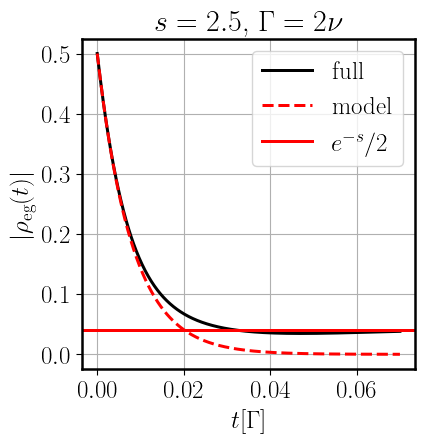

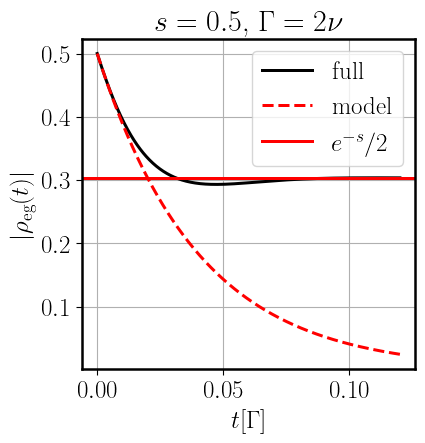

In [4]:
using QuantumOptics
using LinearAlgebra
using PyPlot
include("../PlotSetup.jl")

# ------------------------------------------------------------
# System
# ------------------------------------------------------------

function make_system(nb)
    be = NLevelBasis(2)
    bv = FockBasis(nb)

    σe = transition(be, 1, 2)
    σed = dagger(σe)
    ne_e = σed * σe

    b = destroy(bv)
    bd = dagger(b)

    σ = tensor(σe, identityoperator(bv))
    ne = tensor(ne_e, identityoperator(bv))

    b_op  = tensor(identityoperator(be), b)
    bd_op = tensor(identityoperator(be), bd)

    return (; be, bv, σ, ne, b=b_op, bd=bd_op)
end

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

function full_model(nb; ω0, ν, s, Γ, γ)
    ops = make_system(nb)

    H = ω0 * ops.ne + ν * (ops.bd * ops.b) + sqrt(s) * ν * ops.ne * (ops.b + ops.bd)

    Jv = ops.b + sqrt(s) * ops.ne

    jumps = [
        sqrt(γ) * ops.σ,
        sqrt(Γ) * Jv
    ]

    return ops, H, jumps
end

function effective_model(; ω0, γ, ξ)
    be = NLevelBasis(2)

    σ = transition(be, 1, 2)
    ne = dagger(σ) * σ

    H = ω0 * ne
    jumps = [
        sqrt(γ) * σ,
        sqrt(ξ) * ne
    ]

    return be, H, jumps
end

# ------------------------------------------------------------
# Initial states
# ------------------------------------------------------------

function initial_full(ops)
    ψg = basisstate(ops.be, 1)
    ψe = basisstate(ops.be, 2)
    ψel = normalize(ψg + ψe)

    ψv = fockstate(ops.bv, 0)

    return dm(tensor(ψel, ψv))
end

function initial_eff(be)
    ψg = basisstate(be, 1)
    ψe = basisstate(be, 2)
    return dm(normalize(ψg + ψe))
end

# ------------------------------------------------------------
# Extract coherence
# ------------------------------------------------------------

function coherence_full(times, ρ0, H, jumps, ops)
    _, ρt = timeevolution.master(times, ρ0, H, jumps)
    coh = []
    for ρ in ρt
        ρel = ptrace(ρ, 2)
        push!(coh, ρel.data)
    end
    return coh
end

function coherence_eff(times, ρ0, H, jumps)
    _, ρt = timeevolution.master(times, ρ0, H, jumps)
    return [ρ.data for ρ in ρt]
end

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

function plot_comparison(; nb=16, ω0=0.0, ν=1.0, s=0.02, Γ=0.4, γ=0.0,
                          tmax=30.0, nt=600)

    times = collect(range(0, tmax; length=nt))

    # Full
    ops, Hf, Jf = full_model(nb; ω0=ω0, ν=ν, s=s, Γ=Γ, γ=γ)
    ρ0f = initial_full(ops)
    coh_full = coherence_full(times, ρ0f, Hf, Jf, ops)

    figure(figsize = latex_plot_setup(ratio = 1, scale = 1.8))

    # Plot full

    plot(times / Γ, abs.(map(x->x[1,2], coh_full)), "k-", label="full")
    #plot(times, abs.(map(x->x[2,2], coh_full)), "k-", label="full")

    be, He, Je = effective_model(; ω0=ω0, γ=γ, ξ= s * Γ)
    ρ0e = initial_eff(be)
    coh = coherence_eff(times, ρ0e, He, Je)

    plot(times / Γ, abs.(map(x->x[1,2], coh)), "--", label="model")
    #plot(times, abs.(map(x->x[2,2], coh)), "--", label="model")

    xlabel(L"t[\Gamma]")
    ylabel(L"|\rho_{\rm{eg}}(t)|")
    title("\$s=$s\$, \$\\Gamma=2\\nu\$")
    axhline(exp(-s) * 0.5, color = "red", label = L"e^{-s}/2")
    legend()
    grid(true)

    return nothing
end

# ------------------------------------------------------------
# Run
# ------------------------------------------------------------

plot_comparison(
    nb   = 18,
    ν    = 5.0,
    s    = 2.5,
    Γ    = 10.0,
    tmax = 0.7
)
savefig("../../data/molecule_check_25.pdf", bbox_inches = "tight")

plot_comparison(
    nb   = 18,
    ν    = 5.0,
    s    = 0.5,
    Γ    = 10.0,
    tmax = 1.2
)
savefig("../../data/molecule_check_05.pdf", bbox_inches = "tight")
